In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

import tensorflow as tf
from tensorflow.keras import layers, models
from datetime import datetime
from config import IMG_SIZE, BATCH_SIZE, EPOCHS, LEARNING_RATE, CLASSES, SEED
from utils.plots import LivePlotCallback
# Import your utility function
from utils.preprocess_data import get_garbage_datasets
from utils.model_architectures import build_experimental_model

2000 images, 256x25g RGB

In [2]:
image_categories_path = '../data/images'
image_categories = [
    f'{image_categories_path}/{f}' 
    for f 
    in os.listdir(image_categories_path)
]

image_categories.remove(f'{image_categories_path}/.DS_Store')

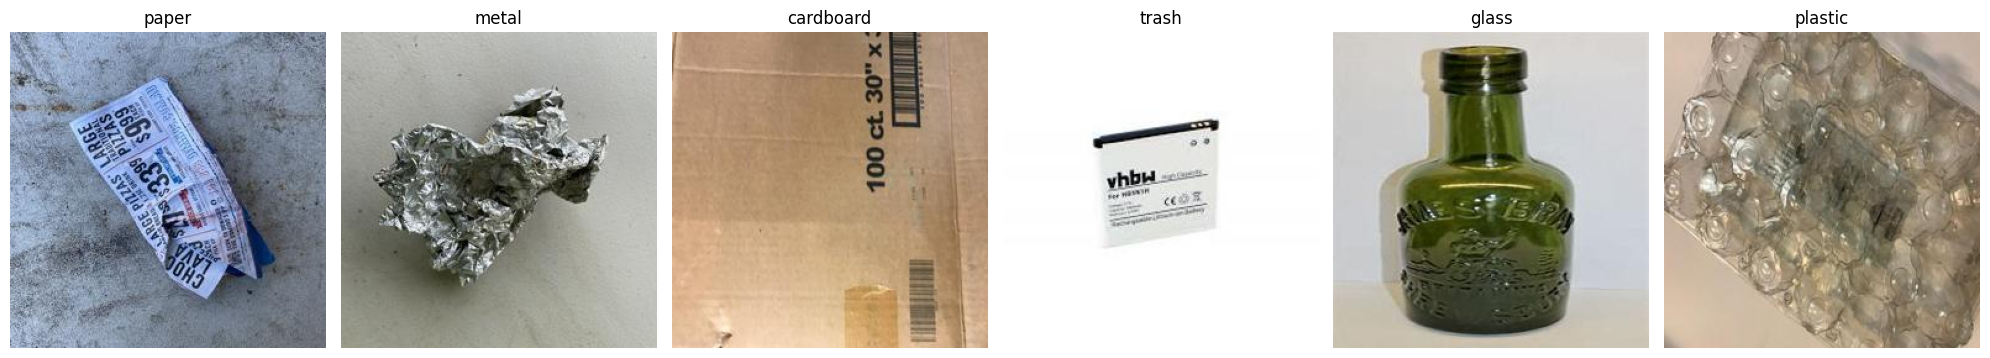

In [3]:
# Create a figure with 1 row and N columns (one for each category)
fig, axes = plt.subplots(1, len(image_categories), figsize=(20, 5))

for i, image_cat in enumerate(image_categories):
    # Get the list of images and pick the first one
    images = os.listdir(image_cat)
    img_path = os.path.join(image_cat, images[0])
    
    img = plt.imread(img_path)
    
    # Plot in the specific subplot slot
    axes[i].imshow(img)
    axes[i].set_title(image_cat.split('/')[-1]) # Set title as category name
    axes[i].axis('off') # Hide the x/y pixel coordinates

plt.tight_layout()
plt.show()

In [4]:
# Load the highly optimized datasets
train_ds, val_ds, class_names = get_garbage_datasets(
    data_dir=image_categories_path, 
    batch_size=BATCH_SIZE, 
    img_size=IMG_SIZE, 
    seed=SEED,
    model_type='custom' # CRITICAL: Tells the pipeline to use 1./255 scaling
)

print(f"Successfully loaded datasets with classes: {CLASSES}")

Found 13901 files belonging to 6 classes.
Using 11121 files for training.


2026-05-22 21:50:15.017040: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-05-22 21:50:15.017083: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-05-22 21:50:15.017092: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-05-22 21:50:15.017108: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-22 21:50:15.017120: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 13901 files belonging to 6 classes.
Using 2780 files for validation.
Successfully loaded datasets with classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [5]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [ ]:
# %%
architectures_to_test = [
    'control', 
    'shallow', 
    'vgg_style', 
    'large_kernel'
]

# Setup experiment directories (Stepping up one level to keep 'src' clean)
model_dir = '../models/experiments/'
log_dir = '../logs/experiments/'
os.makedirs(model_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

experiment_histories = {}

for arch in architectures_to_test:
    print(f"\n{'='*50}")
    print(f"🚀 STARTING EXPERIMENT: {arch.upper()}")
    print(f"{'='*50}\n")
    
    # 1. Build the specific model
    model = build_experimental_model(arch)
    
    # 2. Set up unique callbacks for this architecture
    model_filepath = os.path.join(model_dir, f'{arch}_best.weights.h5') # Fix for Mac Freeze
    csv_log_file = os.path.join(log_dir, f'{arch}_history.csv')
    
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        filepath=model_filepath, 
        monitor='val_accuracy', 
        save_best_only=True, 
        save_weights_only=True, # Critical for Mac
        verbose=1
    )
    
    lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', factor=0.5, patience=3, min_lr=0.00001, verbose=1
    )
    
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1
    )
    
    csv_logger = tf.keras.callbacks.CSVLogger(csv_log_file, append=False)
    
    # 3. Train the model
    history = model.fit(
        train_ds, 
        validation_data=val_ds, 
        epochs=EPOCHS, # Uses your config variable
        callbacks=[checkpoint, lr_scheduler, early_stop, csv_logger],
        verbose=1 
    )
    
    # Store history in memory for immediate plotting
    experiment_histories[arch] = history.history


🚀 STARTING EXPERIMENT: CONTROL

Epoch 1/50


2026-05-22 21:50:15.769439: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.3718 - loss: 1.8597
Epoch 1: val_accuracy improved from None to 0.18058, saving model to ../models/experiments/control_best.weights.h5

Epoch 1: finished saving model to ../models/experiments/control_best.weights.h5
174/174 ━━━━━━━━━━━━━━━━━━━━ 72s 359ms/step - accuracy: 0.3951 - loss: 1.7243 - val_accuracy: 0.1806 - val_loss: 2.4684 - learning_rate: 0.0010
Epoch 2/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.4274 - loss: 1.5470
Epoch 2: val_accuracy improved from 0.18058 to 0.30000, saving model to ../models/experiments/control_best.weights.h5

Epoch 2: finished saving model to ../models/experiments/control_best.weights.h5
174/174 ━━━━━━━━━━━━━━━━━━━━ 65s 370ms/step - accuracy: 0.4355 - loss: 1.5274 - val_accuracy: 0.3000 - val_loss: 1.7810 - learning_rate: 0.0010
Epoch 3/50
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.4822 - loss: 1.3965
Epoch 3: val_accuracy improved from 0.30000 to 0.38741, saving m